Project root  : C:\Users\sarda\Desktop\GlobalMacroPulse
Run timestamp : 2026-03-16 21:26

Files found  : 121 / 121
Files missing: 0

Loading 121 files...
------------------------------------------------------------------------
  OK   VIX Index                     9142 rows  1990-01-02 -> 2026-03-13
  OK   VIX9D Index                   3821 rows  2011-01-03 -> 2026-03-13
  OK   VIX3M Index                   6083 rows  2002-01-02 -> 2026-03-13
  OK   VIX6M Index                   4578 rows  2008-01-02 -> 2026-03-13
  OK   V2X Index                     6923 rows  1999-01-04 -> 2026-03-13
  OK   V1X Index                     8667 rows  1992-01-02 -> 2026-03-13
  OK   VNKY Index                    6171 rows  2001-01-04 -> 2026-03-13
  OK   VHSI Index                    6208 rows  2001-01-02 -> 2026-03-13
  OK   MOVE Index                    9357 rows  1990-01-02 -> 2026-03-13
  OK   SKEW Index                    9102 rows  1990-01-02 -> 2026-03-13
  OK   CPCE Index                    7341 r

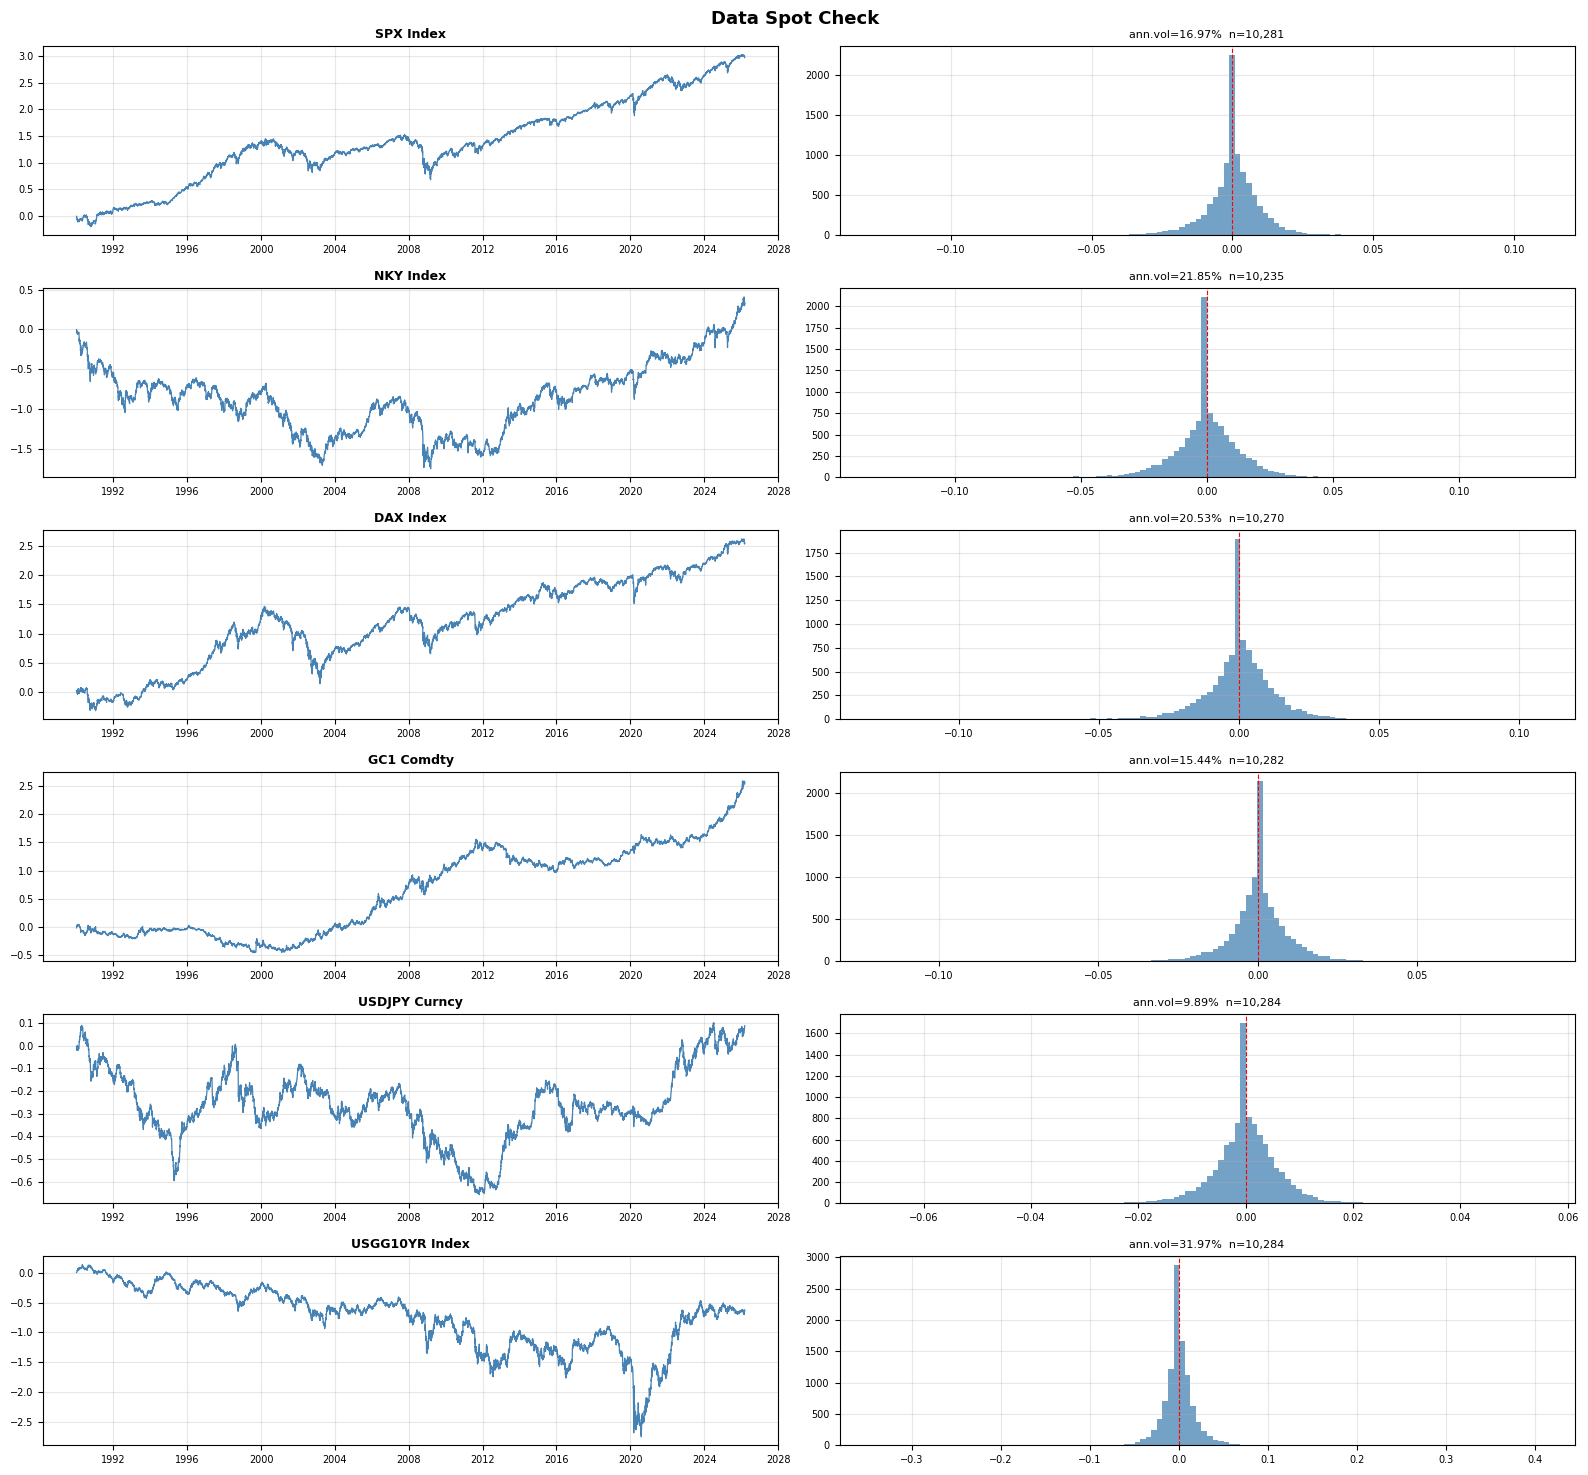


   PIPELINE COMPLETE — Global Macro Pulse
  Total assets    : 117
  Date range      : 1989-07-31 -> 2026-03-13
  Years of data   : 36.6
  Total obs       : 1,014,802

  Assets by branch:
    branch1_fear                        11 assets
    branch2_credit                      8 assets
    branch3_equity                      36 assets
    branch4_rates                       25 assets
    branch5_comfx                       26 assets
    branch6_macro                       11 assets

  Next: notebooks/02_branch1_fear/02_branch1_fear.ipynb


In [2]:
import sys, os, re
import pandas as pd
import numpy as np
import warnings
from datetime import datetime
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import openpyxl

warnings.filterwarnings('ignore')

PROJECT_ROOT = r"C:\Users\sarda\Desktop\GlobalMacroPulse"
sys.path.insert(0, os.path.join(PROJECT_ROOT, "config"))
import settings as cfg

print("Project root  :", PROJECT_ROOT)
print("Run timestamp :", datetime.now().strftime("%Y-%m-%d %H:%M"))

# ── Master registry ───────────────────────────────────────────────────────────
REGISTRY = [
    # VOLATILITY
    ("VIX Index",       "VIX_Index.xlsx",       "volatility",         "branch1_fear"),
    ("VIX9D Index",     "VIX9D_Index.xlsx",     "volatility",         "branch1_fear"),
    ("VIX3M Index",     "VIX3M_Index.xlsx",     "volatility",         "branch1_fear"),
    ("VIX6M Index",     "VIX6M_Index.xlsx",     "volatility",         "branch1_fear"),
    ("V2X Index",       "V2X_Index.xlsx",        "volatility",        "branch1_fear"),
    ("V1X Index",       "V1X_Index.xlsx",        "volatility",        "branch1_fear"),
    ("VNKY Index",      "VNKY_Index.xlsx",       "volatility",        "branch1_fear"),
    ("VHSI Index",      "VHSI_Index.xlsx",       "volatility",        "branch1_fear"),
    ("MOVE Index",      "MOVE_Index.xlsx",       "volatility",        "branch1_fear"),
    ("SKEW Index",      "SKEW_Index.xlsx",       "volatility",        "branch1_fear"),
    ("CPCE Index",      "CPCE_Index.xlsx",       "volatility",        "branch1_fear"),
    # CREDIT
    ("LF98OAS Index",   "LF98OAS_Index.xlsx",   "credit",            "branch2_credit"),
    ("LUACOAS Index",   "LUACOAS_Index.xlsx",   "credit",            "branch2_credit"),
    ("LP01OAS Index",   "LP01OAS_Index.xlsx",   "credit",            "branch2_credit"),
    ("LECPOAS Index",   "LECPOAS_Index.xlsx",   "credit",            "branch2_credit"),
    ("GB3 Govt",        "GB3_Govt.xlsx",         "credit",           "branch2_credit"),
    ("USSO3Z Curncy",   "USSO3Z_Curncy.xlsx",   "credit",            "branch2_credit"),
    ("JPEIGLBL Index",  "JPEIGLBL_Index.xlsx",  "credit",            "branch2_credit"),
    ("GBTPGR10 Credit", "GBTPGR10_Index.xlsx",  "credit",            "branch2_credit"),
    # EQUITIES
    ("NZ50 Index",      "NZ50_Index.xlsx",       "equities",         "branch3_equity"),
    ("AS51 Index",      "AS51_Index.xlsx",       "equities",         "branch3_equity"),
    ("NKY Index",       "NKY_Index.xlsx",        "equities",         "branch3_equity"),
    ("TPX Index",       "TPX_Index.xlsx",        "equities",         "branch3_equity"),
    ("TWSE Index",      "TWSE_Index.xlsx",       "equities",         "branch3_equity"),
    ("KOSPI Index",     "KOSPI_Index.xlsx",      "equities",         "branch3_equity"),
    ("HSI Index",       "HSI_Index.xlsx",        "equities",         "branch3_equity"),
    ("SHSZ300 Index",   "SHSZ300_Index.xlsx",   "equities",          "branch3_equity"),
    ("SHCOMP Index",    "SHCOMP_Index.xlsx",     "equities",         "branch3_equity"),
    ("STI Index",       "STI_Index.xlsx",        "equities",         "branch3_equity"),
    ("NIFTY Index",     "NIFTY_Index.xlsx",      "equities",         "branch3_equity"),
    ("SENSEX Index",    "SENSEX_Index.xlsx",     "equities",         "branch3_equity"),
    ("DAX Index",       "DAX_Index.xlsx",        "equities",         "branch3_equity"),
    ("CAC Index",       "CAC_Index.xlsx",        "equities",         "branch3_equity"),
    ("UKX Index",       "UKX_Index.xlsx",        "equities",         "branch3_equity"),
    ("SMI Index",       "SMI_Index.xlsx",        "equities",         "branch3_equity"),
    ("SX5E Index",      "SX5E_Index.xlsx",       "equities",         "branch3_equity"),
    ("SXXP Index",      "SXXP_Index.xlsx",       "equities",         "branch3_equity"),
    ("IBOV Index",      "IBOV_Index.xlsx",       "equities",         "branch3_equity"),
    ("SPTSX Index",     "SPTSX_Index.xlsx",      "equities",         "branch3_equity"),
    ("SPX Index",       "SPX_Index.xlsx",        "equities",         "branch3_equity"),
    ("INDU Index",      "INDU_Index.xlsx",       "equities",         "branch3_equity"),
    ("CCMP Index",      "CCMP_Index.xlsx",       "equities",         "branch3_equity"),
    ("NDX Index",       "NDX_Index.xlsx",        "equities",         "branch3_equity"),
    ("RTY Index",       "RTY_Index.xlsx",        "equities",         "branch3_equity"),
    ("SOX Index",       "SOX_Index.xlsx",        "equities",         "branch3_equity"),
    ("XLF US Equity",   "XLF_US_Equity.xlsx",   "equities",          "branch3_equity"),
    ("XLE US Equity",   "XLE_US_Equity.xlsx",   "equities",          "branch3_equity"),
    ("XLK US Equity",   "XLK_US_Equity.xlsx",   "equities",          "branch3_equity"),
    ("XLU US Equity",   "XLU_US_Equity.xlsx",   "equities",          "branch3_equity"),
    ("XLV US Equity",   "XLV_US_Equity.xlsx",   "equities",          "branch3_equity"),
    ("XLI US Equity",   "XLI_US_Equity.xlsx",   "equities",          "branch3_equity"),
    ("XLB US Equity",   "XLB_US_Equity.xlsx",   "equities",          "branch3_equity"),
    ("XLY US Equity",   "XLY_US_Equity.xlsx",   "equities",          "branch3_equity"),
    ("XLP US Equity",   "XLP_US_Equity.xlsx",   "equities",          "branch3_equity"),
    ("GDBR10 Equity",   "GDBR10_Index.xlsx",    "equities",          "branch3_equity"),
    # RATES
    ("USGG2YR Index",   "USGG2YR_Index.xlsx",   "rates",             "branch4_rates"),
    ("USGG5YR Index",   "USGG5YR_Index.xlsx",   "rates",             "branch4_rates"),
    ("USGG10YR Index",  "USGG10YR_Index.xlsx",  "rates",             "branch4_rates"),
    ("USGG30YR Index",  "USGG30YR_Index.xlsx",  "rates",             "branch4_rates"),
    ("GDBR2 Index",     "GDBR2_Index.xlsx",     "rates",             "branch4_rates"),
    ("GDBR5 Index",     "GDBR5_Index.xlsx",     "rates",             "branch4_rates"),
    ("GDBR10 Index",    "GDBR10_Index.xlsx",    "rates",             "branch4_rates"),
    ("GDBR30 Index",    "GDBR30_Index.xlsx",    "rates",             "branch4_rates"),
    ("GUKG2 Index",     "GUKG2_Index.xlsx",     "rates",             "branch4_rates"),
    ("GUKG5 Index",     "GUKG5_Index.xlsx",     "rates",             "branch4_rates"),
    ("GUKG10 Index",    "GUKG10_Index.xlsx",    "rates",             "branch4_rates"),
    ("GUKG30 Index",    "GUKG30_Index.xlsx",    "rates",             "branch4_rates"),
    ("GJGB2 Index",     "GJGB2_Index.xlsx",     "rates",             "branch4_rates"),
    ("GJGB5 Index",     "GJGB5_Index.xlsx",     "rates",             "branch4_rates"),
    ("GJGB10 Index",    "GJGB10_Index.xlsx",    "rates",             "branch4_rates"),
    ("GJGB30 Index",    "GJGB30_Index.xlsx",    "rates",             "branch4_rates"),
    ("GBTPGR10 Index",  "GBTPGR10_Index.xlsx",  "rates",            "branch4_rates"),
    ("GFRN10 Index",    "GFRN10_Index.xlsx",    "rates",             "branch4_rates"),
    ("GSWISS10 Index",  "GSWISS10_Index.xlsx",  "rates",             "branch4_rates"),
    ("GACGB10 Index",   "GACGB10_Index.xlsx",   "rates",            "branch4_rates"),
    ("GCAN10YR Index",  "GCAN10YR_Index.xlsx",  "rates",             "branch4_rates"),
    ("GIND10YR Index",  "GIND10YR_Index.xlsx",  "rates",             "branch4_rates"),
    ("GCNY10YR Index",  "GCNY10YR_Index.xlsx",  "rates",             "branch4_rates"),
    ("USGGBE10 Index",  "USGGBE10_Index.xlsx",  "rates",             "branch4_rates"),
    ("USGGBE05 Index",  "USGGBE05_Index.xlsx",  "rates",             "branch4_rates"),
    # COMMODITIES
    ("GC1 Comdty",      "GC1_Comdty.xlsx",      "commodities",       "branch5_comfx"),
    ("SI1 Comdty",      "SI1_Comdty.xlsx",      "commodities",       "branch5_comfx"),
    ("HG1 Comdty",      "HG1_Comdty.xlsx",      "commodities",       "branch5_comfx"),
    ("CL1 Comdty",      "CL1_Comdty.xlsx",      "commodities",       "branch5_comfx"),
    ("CO1 Comdty",      "CO1_Comdty.xlsx",      "commodities",       "branch5_comfx"),
    ("NG1 Comdty",      "NG1_Comdty.xlsx",      "commodities",       "branch5_comfx"),
    ("W1 Index",        "W 1_Index.xlsx",        "commodities",      "branch5_comfx"),
    ("C1 Index",        "C 1_Index.xlsx",        "commodities",      "branch5_comfx"),
    ("S1 Index",        "S 1_Index.xlsx",        "commodities",      "branch5_comfx"),
    ("BCOM Index",      "BCOM_Index.xlsx",       "commodities",      "branch5_comfx"),
    ("BDIY Index",      "BDIY_Index.xlsx",       "commodities",      "branch5_comfx"),
    # FX
    ("DXY Curncy",      "DXY_Curncy.xlsx",       "fx",               "branch5_comfx"),
    ("EURUSD Curncy",   "EURUSD_Curncy.xlsx",   "fx",                "branch5_comfx"),
    ("USDJPY Curncy",   "USDJPY_Curncy.xlsx",   "fx",                "branch5_comfx"),
    ("GBPUSD Curncy",   "GBPUSD_Curncy.xlsx",   "fx",                "branch5_comfx"),
    ("USDCHF Curncy",   "USDCHF_Curncy.xlsx",   "fx",                "branch5_comfx"),
    ("AUDUSD Curncy",   "AUDUSD_Curncy.xlsx",   "fx",                "branch5_comfx"),
    ("USDCAD Curncy",   "USDCAD_Curncy.xlsx",   "fx",                "branch5_comfx"),
    ("NZDUSD Curncy",   "NZDUSD_Curncy.xlsx",   "fx",                "branch5_comfx"),
    ("USDCNY Curncy",   "USDCNY_Curncy.xlsx",   "fx",                "branch5_comfx"),
    ("USDINR Curncy",   "USDINR_Curncy.xlsx",   "fx",                "branch5_comfx"),
    ("USDBRL Curncy",   "USDBRL_Curncy.xlsx",   "fx",                "branch5_comfx"),
    ("USDTRY Curncy",   "USDTRY_Curncy.xlsx",   "fx",                "branch5_comfx"),
    ("USDZAR Curncy",   "USDZAR_Curncy.xlsx",   "fx",                "branch5_comfx"),
    ("USDMXN Curncy",   "USDMXN_Curncy.xlsx",   "fx",               "branch5_comfx"),
    ("AUDJPY Curncy",   "AUDJPY_Curncy.xlsx",   "fx",                "branch5_comfx"),
    # MACRO
    ("CESIUSD Index",   "CESIUSD_Index.xlsx",   "macro_fundamentals","branch6_macro"),
    ("CESIEUR Index",   "CESIEUR_Index.xlsx",   "macro_fundamentals","branch6_macro"),
    ("CESICNY Index",   "CESICNY_Index.xlsx",   "macro_fundamentals","branch6_macro"),
    ("CESIEM Index",    "CESIEM_Index.xlsx",    "macro_fundamentals", "branch6_macro"),
    ("CESIG10 Index",   "CESIG10_Index.xlsx",   "macro_fundamentals","branch6_macro"),
    ("NAPMPMI Index",   "NAPMPMI_Index.xlsx",   "macro_fundamentals","branch6_macro"),
    ("NAPMNMI Index",   "NAPMNMI_Index.xlsx",   "macro_fundamentals","branch6_macro"),
    ("MPMIEZMA Index",  "MPMIEZMA_Index.xlsx",  "macro_fundamentals","branch6_macro"),
    ("CPMINDX Index",   "CPMINDX_Index.xlsx",   "macro_fundamentals","branch6_macro"),
    ("MPMIJPMA Index",  "MPMIJPMA_Index.xlsx",  "macro_fundamentals","branch6_macro"),
    ("MPMIGBMA Index",  "MPMIGBMA_Index.xlsx",  "macro_fundamentals","branch6_macro"),
    ("MPMIINMA Index",  "MPMIINMA_Index.xlsx",  "macro_fundamentals","branch6_macro"),
    ("CONSSENT Index",  "CONSSENT_Index.xlsx",  "macro_fundamentals","branch6_macro"),
    ("CONCCONF Index",  "CONCCONF_Index.xlsx",  "macro_fundamentals","branch6_macro"),
    ("LEI TOTL Index",  "LEI_TOTL_Index.xlsx",  "macro_fundamentals","branch6_macro"),
]

FOLDER_MAP = {
    "volatility":         cfg.RAW_FOLDERS["volatility"],
    "credit":             cfg.RAW_FOLDERS["credit"],
    "equities":           cfg.RAW_FOLDERS["equity"],
    "rates":              cfg.RAW_FOLDERS["rates"],
    "commodities":        cfg.RAW_FOLDERS["commodity"],
    "fx":                 cfg.RAW_FOLDERS["fx"],
    "macro_fundamentals": cfg.RAW_FOLDERS["macro"],
}

# ── Check files on disk ───────────────────────────────────────────────────────
file_status = []
for ticker, filename, folder, branch in REGISTRY:
    full_path = os.path.join(FOLDER_MAP[folder], filename)
    file_status.append({
        "ticker": ticker, "filename": filename, "folder": folder,
        "branch": branch, "exists": os.path.exists(full_path), "full_path": full_path
    })

status_df = pd.DataFrame(file_status)
present   = status_df[status_df["exists"]]
missing   = status_df[~status_df["exists"]]
print(f"\nFiles found  : {len(present)} / {len(status_df)}")
print(f"Files missing: {len(missing)}")
if not missing.empty:
    print(missing[["ticker","filename","folder"]].to_string(index=False))


# ── Parser — built specifically for Bloomberg HP xlsx structure ───────────────
def parse_bloomberg_xlsx(filepath):
    """
    Bloomberg HP xlsx structure:
      Row 1: Security name
      Row 2: Start Date
      Row 3: End Date      <- we use this to recover the missing date in row 8
      Row 4: Period
      Row 5: Currency
      Row 6: blank
      Row 7: Headers  -> Date | PX_LAST | BID (or similar)
      Row 8: ArrayFormula in date cell (unreadable) + first price value
      Row 9+: Proper datetime dates + numeric prices
    
    Strategy:
      1. Read end date from row 3 (cell B3) using openpyxl
      2. Read headers from row 7
      3. Read data from row 9 onwards (skip the formula row 8)
      4. Prepend row 8 price with the end date recovered from metadata
    """
    try:
        # ── Step 1: Extract end date and first price from raw openpyxl ───────
        wb  = openpyxl.load_workbook(filepath, data_only=True)
        ws  = wb.active
        
        # End date is in row 3, column B (the metadata section)
        end_date_raw = ws.cell(row=3, column=2).value
        end_date = pd.to_datetime(end_date_raw, dayfirst=True, errors='coerce') if end_date_raw else None
        
        # First price value is in row 8, column B
        first_price_raw = ws.cell(row=8, column=2).value
        try:
            first_price = float(first_price_raw) if first_price_raw is not None else None
        except:
            first_price = None

        wb.close()

        # ── Step 2: Read main data block from row 9 onwards ──────────────────
        # header=0 because we skip to row 7 (0-indexed: skiprows=6)
        # then row 7 becomes our header, row 8 (formula) is skipped via skiprows list
        df = pd.read_excel(
            filepath,
            skiprows=[0,1,2,3,4,5,7],   # skip rows 1-6 (metadata) and row 8 (formula)
            header=0                      # row 7 becomes header
        )

        # ── Step 3: Standardize column names ─────────────────────────────────
        df.columns = [str(c).strip().upper().replace(' ', '_') for c in df.columns]
        date_col   = df.columns[0]

        # ── Step 4: Parse dates ───────────────────────────────────────────────
        df[date_col] = pd.to_datetime(df[date_col], dayfirst=True, errors='coerce')
        df = df[df[date_col].notna()]
        df.index      = df[date_col]
        df.index.name = "date"
        df.drop(columns=[date_col], inplace=True)

        # ── Step 5: Rename price columns to standard names ───────────────────
        rename_map = {}
        for col in df.columns:
            u = col.upper()
            if any(k in u for k in ['LAST','CLOSE','PX_L','VALUE','OFFICIAL','PRICE']):
                rename_map[col] = 'PX_LAST'
            elif 'BID' in u:
                rename_map[col] = 'BID'
            elif 'OPEN' in u:
                rename_map[col] = 'PX_OPEN'
            elif 'HIGH' in u:
                rename_map[col] = 'PX_HIGH'
            elif 'LOW'  in u:
                rename_map[col] = 'PX_LOW'
        df.rename(columns=rename_map, inplace=True)

        # If still no PX_LAST, take the first numeric column
        if 'PX_LAST' not in df.columns:
            for col in df.columns:
                test = pd.to_numeric(df[col], errors='coerce')
                if test.notna().sum() > 10:
                    df.rename(columns={col: 'PX_LAST'}, inplace=True)
                    break

        # ── Step 6: Convert to numeric ────────────────────────────────────────
        for col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

        df = df[~df.index.duplicated(keep='last')].sort_index()
        df = df.dropna(subset=['PX_LAST'])

        # ── Step 7: Prepend the formula row (row 8) using recovered end date ──
        if end_date is not None and first_price is not None:
            # Only prepend if this date is not already in df
            if end_date not in df.index:
                extra_row = pd.DataFrame(
                    {'PX_LAST': [first_price]},
                    index=pd.DatetimeIndex([end_date], name='date')
                )
                df = pd.concat([df, extra_row]).sort_index()

        if len(df) < 50:
            return None, f"Too few rows after parsing: {len(df)}"

        return df, None

    except Exception as e:
        return None, str(e)


# ── Load all files ────────────────────────────────────────────────────────────
load_log     = []
close_series = []

print(f"\nLoading {len(present)} files...")
print("-" * 72)

for _, row in present.iterrows():
    ticker = row["ticker"]
    df, error = parse_bloomberg_xlsx(row["full_path"])
    if df is not None:
        close_series.append(df['PX_LAST'].rename(ticker))
        entry = {
            "ticker": ticker, "branch": row["branch"], "status": "OK",
            "rows": len(df), "actual_start": str(df.index.min().date()),
            "actual_end": str(df.index.max().date()), "error": ""
        }
        print(f"  OK   {ticker:<28} {len(df):>5} rows  {entry['actual_start']} -> {entry['actual_end']}")
    else:
        entry = {
            "ticker": ticker, "branch": row["branch"], "status": "FAILED",
            "rows": 0, "actual_start": "", "actual_end": "", "error": error
        }
        print(f"  FAIL {ticker:<28} {error}")
    load_log.append(entry)

load_log_df = pd.DataFrame(load_log)
n_ok   = (load_log_df["status"] == "OK").sum()
n_fail = (load_log_df["status"] == "FAILED").sum()
print("-" * 72)
print(f"Result: {n_ok} loaded  |  {n_fail} failed")


# ── Build master prices and log returns ───────────────────────────────────────
prices_all    = pd.concat(close_series, axis=1, join="outer").sort_index()
prices_all.dropna(how="all", inplace=True)
prices_filled = prices_all.ffill(limit=3)
log_returns   = np.log(prices_filled / prices_filled.shift(1))
log_returns.dropna(how="all", inplace=True)

print(f"\nPrices  : {prices_all.shape[0]:,} dates x {prices_all.shape[1]} assets")
print(f"Returns : {log_returns.shape[0]:,} dates x {log_returns.shape[1]} assets")
print(f"Range   : {log_returns.index.min().date()} -> {log_returns.index.max().date()}")
print(f"Years   : {(log_returns.index.max()-log_returns.index.min()).days/365.25:.1f}")


# ── Sanity check ──────────────────────────────────────────────────────────────
flags = []
for col in log_returns.columns:
    s   = log_returns[col].dropna()
    big = s[s.abs() > 0.25]
    for dt, val in big.items():
        flags.append({"ticker": col, "date": dt.date(), "log_return": round(val,4)})
if flags:
    flags_df = pd.DataFrame(flags).sort_values("log_return", key=abs, ascending=False)
    print(f"\n{len(flags_df)} single-day moves >25%:")
    print(flags_df.head(20).to_string(index=False))
else:
    print("\nNo suspicious returns. Data looks clean.")


# ── Save ──────────────────────────────────────────────────────────────────────
prices_filled.to_csv(cfg.ALIGNED_PRICES_FILE)
log_returns.to_csv(cfg.MASTER_RETURNS_FILE)
load_log_df.to_csv(os.path.join(cfg.CONFIG_PATH, "load_log.csv"), index=False)

meta = []
for col in log_returns.columns:
    s = log_returns[col].dropna()
    if s.empty: continue
    meta.append({
        "ticker": col,
        "actual_start": str(s.index.min().date()),
        "actual_end":   str(s.index.max().date()),
        "n_obs":        len(s),
        "n_years":      round(len(s)/252, 1),
        "ann_vol":      round(s.std()*np.sqrt(252), 4),
        "sharpe_proxy": round(s.mean()/s.std()*np.sqrt(252), 3) if s.std() > 0 else 0
    })
pd.DataFrame(meta).to_csv(
    os.path.join(cfg.PROC_PATH, "returns", "metadata.csv"), index=False
)
print(f"\nAll files saved to data/processed/")


# ── Spot check plots ──────────────────────────────────────────────────────────
CANDIDATES   = ["SPX Index","NKY Index","DAX Index","GC1 Comdty","USDJPY Curncy","USGG10YR Index"]
spot_tickers = [t for t in CANDIDATES if t in log_returns.columns] or list(log_returns.columns[:6])

fig, axes = plt.subplots(len(spot_tickers), 2, figsize=(16, len(spot_tickers)*2.5))
if len(spot_tickers) == 1:
    axes = np.array([axes])
fig.suptitle("Data Spot Check", fontsize=13, fontweight="bold")

for idx, ticker in enumerate(spot_tickers):
    s = log_returns[ticker].dropna()
    axes[idx,0].plot(s.cumsum(), lw=0.9, color="steelblue")
    axes[idx,0].set_title(ticker, fontsize=9, fontweight="bold")
    axes[idx,0].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    axes[idx,0].tick_params(labelsize=7); axes[idx,0].grid(alpha=0.3)
    axes[idx,1].hist(s, bins=120, color="steelblue", alpha=0.75, edgecolor="none")
    axes[idx,1].axvline(0, color="red", lw=0.8, ls="--")
    axes[idx,1].set_title(f"ann.vol={s.std()*np.sqrt(252):.2%}  n={len(s):,}", fontsize=8)
    axes[idx,1].tick_params(labelsize=7); axes[idx,1].grid(alpha=0.3)

plt.tight_layout()
chart_path = os.path.join(cfg.OUT_PATH, "charts", "01_data_spot_check.png")
plt.savefig(chart_path, dpi=150, bbox_inches="tight")
plt.show()


# ── Final summary ─────────────────────────────────────────────────────────────
print("\n" + "="*54)
print("   PIPELINE COMPLETE — Global Macro Pulse")
print("="*54)
print(f"  Total assets    : {log_returns.shape[1]}")
print(f"  Date range      : {log_returns.index.min().date()} -> {log_returns.index.max().date()}")
print(f"  Years of data   : {(log_returns.index.max()-log_returns.index.min()).days/365.25:.1f}")
print(f"  Total obs       : {log_returns.notna().sum().sum():,}")
print("\n  Assets by branch:")
for branch, group in load_log_df[load_log_df["status"]=="OK"].groupby("branch"):
    print(f"    {branch:<35} {len(group)} assets")
print("\n  Next: notebooks/02_branch1_fear/02_branch1_fear.ipynb")
print("="*54)

In [3]:
import openpyxl
wb = openpyxl.load_workbook(r"C:\Users\sarda\Desktop\GlobalMacroPulse\data\raw\macro_fundamentals\MPMIEZMA_Index.xlsx", data_only=True)
ws = wb.active
for row in range(1, 15):
    print(f"Row {row}: {[ws.cell(row=row, column=c).value for c in range(1,5)]}")
wb.close()

Row 1: ['Security', 'MPMIEZMA Index', None, None]
Row 2: ['Start Date', datetime.datetime(2023, 2, 28, 0, 0), None, None]
Row 3: ['End Date', datetime.datetime(2026, 2, 28, 0, 0), None, None]
Row 4: ['Period', 'D', None, None]
Row 5: [None, None, None, None]
Row 6: ['Date', 'PX_LAST', 'IVOL_MID', None]
Row 7: [datetime.datetime(2026, 2, 28, 0, 0), 50.8, '#N/A N/A', None]
Row 8: [datetime.datetime(2026, 1, 31, 0, 0), 49.5, '#N/A N/A', None]
Row 9: [datetime.datetime(2025, 12, 31, 0, 0), 48.8, '#N/A N/A', None]
Row 10: [datetime.datetime(2025, 11, 30, 0, 0), 49.6, '#N/A N/A', None]
Row 11: [datetime.datetime(2025, 10, 31, 0, 0), 50, '#N/A N/A', None]
Row 12: [datetime.datetime(2025, 9, 30, 0, 0), 49.8, '#N/A N/A', None]
Row 13: [datetime.datetime(2025, 8, 31, 0, 0), 50.7, '#N/A N/A', None]
Row 14: [datetime.datetime(2025, 7, 31, 0, 0), 49.8, '#N/A N/A', None]


In [6]:
import sys, os
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

PROJECT_ROOT = r"C:\Users\sarda\Desktop\GlobalMacroPulse"
sys.path.insert(0, os.path.join(PROJECT_ROOT, "config"))
import settings as cfg

# ── Load the aligned prices we already saved ─────────────────────────────────
prices = pd.read_csv(cfg.ALIGNED_PRICES_FILE, index_col="date", parse_dates=True)
print(f"Loaded prices: {prices.shape}")

# ── Define transformation groups ──────────────────────────────────────────────

# Group 1: LOG RETURNS — price-like series
LOG_RETURN_TICKERS = [
    # Equities
    "NZ50 Index","AS51 Index","NKY Index","TPX Index","TWSE Index","KOSPI Index",
    "HSI Index","SHSZ300 Index","SHCOMP Index","STI Index","NIFTY Index","SENSEX Index",
    "DAX Index","CAC Index","UKX Index","SMI Index","SX5E Index","SXXP Index",
    "IBOV Index","SPTSX Index","SPX Index","INDU Index","CCMP Index","NDX Index",
    "RTY Index","SOX Index",
    "XLF US Equity","XLE US Equity","XLK US Equity","XLU US Equity","XLV US Equity",
    "XLI US Equity","XLB US Equity","XLY US Equity","XLP US Equity",
    # Volatility indices (behave like prices)
    "VIX Index","VIX9D Index","VIX3M Index","VIX6M Index",
    "V2X Index","V1X Index","VNKY Index","VHSI Index","MOVE Index","SKEW Index",
    "CPCE Index",
    # Commodities
    "GC1 Comdty","SI1 Comdty","HG1 Comdty","CL1 Comdty","CO1 Comdty","NG1 Comdty",
    "W1 Index","C1 Index","S1 Index","BCOM Index","BDIY Index",
    # FX
    "DXY Curncy","EURUSD Curncy","USDJPY Curncy","GBPUSD Curncy","USDCHF Curncy",
    "AUDUSD Curncy","USDCAD Curncy","NZDUSD Curncy","USDCNY Curncy","USDINR Curncy",
    "USDBRL Curncy","USDTRY Curncy","USDZAR Curncy","USDMXN Curncy","AUDJPY Curncy",
]

# Group 2: FIRST DIFFERENCE — rate/spread levels
DIFF_TICKERS = [
    # US rates
    "USGG2YR Index","USGG5YR Index","USGG10YR Index","USGG30YR Index",
    "USGGBE10 Index","USGGBE05 Index",
    "GDBR10 Equity",
    # German rates
    "GDBR2 Index","GDBR5 Index","GDBR10 Index","GDBR30 Index",
    # UK rates
    "GUKG2 Index","GUKG5 Index","GUKG10 Index","GUKG30 Index",
    # Japan rates
    "GJGB2 Index","GJGB5 Index","GJGB10 Index","GJGB30 Index",
    # Other rates
    "GBTPGR10 Index","GFRN10 Index","GSWISS10 Index","GACGB10 Index",
    "GCAN10YR Index","GIND10YR Index","GCNY10YR Index",
    # Credit spreads
    "LF98OAS Index","LUACOAS Index","LP01OAS Index","LECPOAS Index",
    "JPEIGLBL Index","GBTPGR10 Credit",
    # Money market
    "GB3 Govt","USSO3Z Curncy",
]

# Group 3: LEVEL — use as-is (already in index/score form)
LEVEL_TICKERS = [
    "CESIUSD Index","CESIEUR Index","CESICNY Index","CESIEM Index","CESIG10 Index",
    "NAPMPMI Index","NAPMNMI Index","CPMINDX Index",
    "CONSSENT Index","CONCCONF Index","LEI TOTL Index",
]

# ── Compute transformations ───────────────────────────────────────────────────
prices_filled = prices.ffill(limit=3)

# Log returns
log_ret = np.log(
    prices_filled[LOG_RETURN_TICKERS].clip(lower=1e-6) /
    prices_filled[LOG_RETURN_TICKERS].clip(lower=1e-6).shift(1)
)

# First differences (in original units — basis points for rates/spreads)
first_diff = prices_filled[DIFF_TICKERS].diff()

# Levels (no transformation)
levels = prices_filled[LEVEL_TICKERS]

# ── Combine into one master returns dataframe ─────────────────────────────────
# All three sit side by side — each column uses the right transformation
returns_master = pd.concat([log_ret, first_diff, levels], axis=1)
returns_master.dropna(how="all", inplace=True)

print(f"\nReturns master: {returns_master.shape}")
print(f"Date range    : {returns_master.index.min().date()} -> {returns_master.index.max().date()}")

# ── Sanity check — no more inf/-inf ──────────────────────────────────────────
inf_count = np.isinf(returns_master.values).sum()
nan_count = returns_master.isna().sum().sum()
print(f"\nInf values    : {inf_count}  (should be 0)")
print(f"NaN values    : {nan_count}  (expected — different start dates)")

# ── Check suspicious moves in log return group only ──────────────────────────
flags = []
for col in LOG_RETURN_TICKERS:
    if col not in returns_master.columns: continue
    s   = returns_master[col].dropna()
    big = s[s.abs() > 0.25]
    for dt, val in big.items():
        flags.append({"ticker": col, "date": dt.date(), "log_return": round(val,4)})

if flags:
    flags_df = pd.DataFrame(flags).sort_values("log_return", key=abs, ascending=False)
    print(f"\n{len(flags_df)} equity/commodity/FX moves >25% (verify these are real):")
    print(flags_df.head(20).to_string(index=False))
else:
    print("\nNo suspicious returns in price series. Clean.")

# ── Save the corrected master returns ────────────────────────────────────────
returns_master.to_csv(cfg.MASTER_RETURNS_FILE)
print(f"\nSaved corrected returns to: {cfg.MASTER_RETURNS_FILE}")

# ── Save transformation metadata ─────────────────────────────────────────────
transform_meta = (
    [(t, "log_return")  for t in LOG_RETURN_TICKERS if t in returns_master.columns] +
    [(t, "first_diff")  for t in DIFF_TICKERS       if t in returns_master.columns] +
    [(t, "level")       for t in LEVEL_TICKERS       if t in returns_master.columns]
)
pd.DataFrame(transform_meta, columns=["ticker","transformation"]).to_csv(
    os.path.join(cfg.CONFIG_PATH, "transformations.csv"), index=False
)
print(f"Saved transformation map to: config/transformations.csv")

# ── Summary ───────────────────────────────────────────────────────────────────
print("\n" + "="*50)
print(f"  Log return series  : {len([t for t in LOG_RETURN_TICKERS if t in returns_master.columns])}")
print(f"  First diff series  : {len([t for t in DIFF_TICKERS if t in returns_master.columns])}")
print(f"  Level series       : {len([t for t in LEVEL_TICKERS if t in returns_master.columns])}")
print(f"  Total              : {returns_master.shape[1]}")
print("="*50)

Loaded prices: (10331, 117)

Returns master: (10330, 117)
Date range    : 1989-07-31 -> 2026-03-13

Inf values    : 0  (should be 0)
NaN values    : 181070  (expected — different start dates)

1469 equity/commodity/FX moves >25% (verify these are real):
     ticker       date  log_return
 CL1 Comdty 2020-04-20    -16.7208
 CL1 Comdty 2020-04-21     16.1191
 CPCE Index 1997-02-14     -1.2292
 CPCE Index 2003-06-18     -1.2130
 CPCE Index 1997-02-13      1.1838
VIX9D Index 2018-02-05      1.1462
 CPCE Index 2022-12-28      1.0739
 CPCE Index 2003-06-17      0.9960
VIX9D Index 2024-12-18      0.9728
 CPCE Index 2022-12-21      0.9565
 CPCE Index 2001-09-24     -0.9520
 CPCE Index 2003-12-31      0.9430
 CPCE Index 2024-01-10      0.9326
 CPCE Index 2022-11-16      0.9232
 VNKY Index 2024-08-05      0.8759
 CPCE Index 2004-03-31      0.8718
 CPCE Index 2004-04-01     -0.8503
 CPCE Index 2003-09-02     -0.8131
VIX9D Index 2017-05-17      0.8114
 CPCE Index 2003-05-19      0.8109

Saved corr